In [1]:
%matplotlib inline

### Дома по регионам

In [104]:
import pandas as pd
import psycopg2
from ydata_profiling import ProfileReport
import os
import re
import logging
import json
import requests


def get_usd_to_uzs():
    url = "https://cbu.uz/ru/arkhiv-kursov-valyut/json/"
    try:
        response = requests.get(url)
        data = response.json()
        for currency in data:
            if currency["Ccy"] == "USD":
                return float(currency["Rate"])
    except Exception as e:
        print("Ошибка получения курса:", e)
        return 12895

# Подключение и загрузка данных
usd_to_uzs = get_usd_to_uzs()
print("Текущий курс USD/UZS:", usd_to_uzs)




# Настройка логирования
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logging.info("Начало выполнения скрипта")






# Подключение к PostgreSQL
conn = psycopg2.connect(
    dbname="postgres",
    user="postgres",
    password=os.getenv('POSTGRES_PASSWORD', 'your_password'),
    host="127.0.0.1",
    port="5432"
)





# SQL-запрос
query = f"""
WITH corrected_areas AS (
    SELECT *,
           CASE WHEN currency = 'UYE' THEN price ELSE price / {usd_to_uzs} END AS price_uye,
           CASE WHEN currency = 'UYE' THEN price * {usd_to_uzs} ELSE price END AS price_uz
    FROM houses
    WHERE createdtime >= '2024-01-01'
        AND total_area IS NOT NULL
        AND price IS NOT NULL AND price > 0
        AND regionname = 'Ташкентская область'
        AND house_type NOT IN ('Панельный', 'Деревянный')  -- 🔥
        AND house_subtype NOT IN ('Таунхаус', 'Флигель')  -- 🔥
        AND number_of_rooms  IS NOT NULL AND number_of_rooms <= 10
        AND ceiling_height IS NOT NULL AND ceiling_height >= 2   -- ✅ УСЛОВИЕ ДЛЯ ОТСЕВА
        AND (
            (CASE WHEN currency = 'UYE' THEN price ELSE price / {usd_to_uzs} END) BETWEEN 30000 AND 550000  --- # 1-й перцентиль (~30,000$) , 95-й перцентиль (550,000$)
        )
),

cleaned_floors AS (
    SELECT *,
           LEAST(total_floors, 4) AS total_floors_limited,
           LEAST(ceiling_height, 4) AS ceiling_height_limited
    FROM corrected_areas
)
SELECT
  url,
  plot,
  price_uye,
  description,
  title,
  number_of_rooms,
  total_area,
  price,
  currency,
  regionname,
  cityname,
  createdtime,
  total_floors_limited as total_floors,
  furnished,
  repairs,
  comission,
  wc,
  house_type,
  CASE
    WHEN house_subtype = 'Дача' THEN 'Дача'
    ELSE 'Дом'
  END AS house_subtype_normalized,
  total_living_area,
  water,
  heating,
  gas,
  electricity,
  year_of_construction_sale,
  CASE
    WHEN districtname = 'Мирзо-Улугбексий район' THEN 'Мирзо-Улугбекский район'
    ELSE districtname
END AS districtname,
  layout,
  ceiling_height_limited as ceiling_height,
  location,
  price_uz
FROM cleaned_floors;
"""

# Загружаем данные из PostgreSQL
df = pd.read_sql(query, conn)
conn.close()


# === Извлечение площади участка из description (в сотках) ===
# 🔍 Извлечение plot из description, если указано в сотках
def extract_plot_from_description_and_title(row):
    # Проверяем description
    if not pd.isnull(row['description']):
        text = row['description'].lower().replace(" ", "")
        pattern = r'(\d{1,3}(?:[.,]\d{1,2})?)(?:\s*)?(сот|соток|сотих|сотх|сотҳ|sot|sotih|sotix|sotx|сотиқ|sotik|сотиқи|-соток)'
        match = re.search(pattern, text)
        if match:
            value_str = match.group(1).replace(",", ".")
            try:
                return float(value_str) * 100  # Перевод соток в м²
            except:
                pass

    # Если в description не нашли, проверяем title
    if not pd.isnull(row['title']):
        text = row['title'].lower().replace(" ", "")
        pattern = r'(\d{1,3}(?:[.,]\d{1,2})?)(?:\s*)?(сот|соток|сотих|сотх|сотҳ|sot|sotih|sotix|sotx|сотиқ|sotik|сотиқи|-соток)'
        match = re.search(pattern, text)
        if match:
            value_str = match.group(1).replace(",", ".")
            try:
                return float(value_str) * 100  # Перевод соток в м²
            except:
                return None
    return None

# Применяем функцию к DataFrame (axis=1 для работы со строками)
df["plot_in_desc"] = df.apply(extract_plot_from_description_and_title, axis=1)

df["plot"] = df["plot_in_desc"].combine_first(df["plot"])

2025-07-11 16:39:27,304 - INFO - Начало выполнения скрипта


Текущий курс USD/UZS: 12634.34


/var/folders/q0/042269_x4qggn_0htwwx67qr0000gq/T/ipykernel_3414/354121367.py:119: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [3]:
import pandas as pd
import psycopg2
from ydata_profiling import ProfileReport
import os
import re
import logging
import json
import requests


def get_usd_to_uzs():
    url = "https://cbu.uz/ru/arkhiv-kursov-valyut/json/"
    try:
        response = requests.get(url)
        data = response.json()
        for currency in data:
            if currency["Ccy"] == "USD":
                return float(currency["Rate"])
    except Exception as e:
        print("Ошибка получения курса:", e)
        return 12895

# Подключение и загрузка данных
usd_to_uzs = get_usd_to_uzs()
print("Текущий курс USD/UZS:", usd_to_uzs)




# Настройка логирования
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logging.info("Начало выполнения скрипта")






# Подключение к PostgreSQL
conn = psycopg2.connect(
    dbname="postgres",
    user="postgres",
    password=os.getenv('POSTGRES_PASSWORD', 'your_password'),
    host="127.0.0.1",
    port="5432"
)





# SQL-запрос
query = f"""
WITH corrected_areas AS (
    SELECT *,
           CASE WHEN currency = 'UYE' THEN price ELSE price / {usd_to_uzs} END AS price_uye,
           CASE WHEN currency = 'UYE' THEN price * {usd_to_uzs} ELSE price END AS price_uz
    FROM houses
    WHERE createdtime >= '2024-01-01'
        AND total_area IS NOT NULL
        AND price IS NOT NULL AND price > 0
        AND regionname = 'Ташкентская область'
        AND house_type NOT IN ('Панельный', 'Деревянный')  -- 🔥
        AND house_subtype NOT IN ('Таунхаус', 'Флигель')  -- 🔥
        AND number_of_rooms  IS NOT NULL AND number_of_rooms <= 10
        AND ceiling_height IS NOT NULL AND ceiling_height >= 2   -- ✅ УСЛОВИЕ ДЛЯ ОТСЕВА
        AND (
            (CASE WHEN currency = 'UYE' THEN price ELSE price / {usd_to_uzs} END) BETWEEN 30000 AND 550000  --- # 1-й перцентиль (~30,000$) , 95-й перцентиль (550,000$)
        )
),

cleaned_floors AS (
    SELECT *,
           LEAST(total_floors, 4) AS total_floors_limited,
           LEAST(ceiling_height, 4) AS ceiling_height_limited
    FROM corrected_areas
)
SELECT
  url,
  price_uye,
  description,
  title,
  number_of_rooms,
  total_area,
  price,
  currency,
  regionname,
  cityname,
  createdtime,
  total_floors_limited as total_floors,
  furnished,
  repairs,
  comission,
  wc,
  house_type,
  CASE
    WHEN house_subtype = 'Дача' THEN 'Дача'
    ELSE 'Дом'
  END AS house_subtype_normalized,
  total_living_area,
  water,
  heating,
  gas,
  electricity,
  plot,
  year_of_construction_sale,
  CASE
    WHEN districtname = 'Мирзо-Улугбексий район' THEN 'Мирзо-Улугбекский район'
    ELSE districtname
END AS districtname,
  layout,
  ceiling_height_limited as ceiling_height,
  location,
  price_uz
FROM cleaned_floors;
"""

# Загружаем данные из PostgreSQL
df = pd.read_sql(query, conn)
conn.close()


# 🔹 Нормализация для  repairs
import re

def repairs_grouped(repairs):
    if pd.isnull(repairs) or str(repairs).strip() == '':
        return None
    s = str(repairs).lower().strip()

    if 'под снос' in s:
        return 'Под снос'
    if ('требует' in s) or ('предчистовая отделка' in s) or ('не достроен' in s) or ('черновая отделка' in s) :
        return 'Требует ремонта'


    if 'авторский проект, евроремонт' in s:
        return 'Авторский проект'
    if 'авторский проект, средний ремонт' in s:
        return 'Авторский проект'
    if 'средний ремонт' in s:
        return 'Средний'
    if 'евроремонт' in s:
        return 'Евроремонт'
    return 'Средний'   # по умолчанию всё прочее



# 🔹 Нормализация для  water

def water_grouped(water):
    if pd.isnull(water):
        return None
    s = str(water).lower().strip()
    if s == '':
        return 'Нет данных'
    if ('нет' in s) and ('возможно' not in s):
        return 'Нет воды'
    if 'центральное' in s:
        return 'Центральное'
    if ('в доме' in s) and ('центральное' not in s):
        return 'В доме (автономное)'
    if ('скважина' in s) or ('колодец' in s):
        return 'Скважина/Колодец'
    if 'возможно подведение' in s:
        return 'Возможно подведение'
    if 'на границе' in s:
        return 'На границе'
    return 'Смешанное'



# 🔹 Нормализация для  heating

def heating_grouped(heating):
    if pd.isnull(heating):
        return None
    s = str(heating).lower().strip()
    if s == 'none':
        return 'None'
    if 'центральное' in s:
        return 'Центральное'
    if 'без отопления' in s:
        return 'Без отопления'
    if (
            ('на газе' in s) and
            ('центральное' not in s) and
            ('электричес' not in s) and
            ('твердом топливе' not in s) and
            ('жидком топливе' not in s)
    ):
        return 'Газовое'
    if (
            ('электричес' in s) and
            ('центральное' not in s) and
            ('на газе' not in s) and
            ('твердом топливе' not in s) and
            ('жидком топливе' not in s)
    ):
        return 'Электрическое'
    if ('твердом топливе' in s) or ('жидком топливе' in s):
        return 'Твердое или жидкое топливо'
    return 'Смешанное'


df['repairs_grouped'] = df['repairs'].apply(repairs_grouped)
df['water_grouped'] = df['water'].apply(water_grouped)
df['heating_grouped'] = df['heating'].apply(heating_grouped)


# 🔹 Нормализация для  location

# Список всех возможных категорий локаций
location_categories = [
    'В городе',
    'В пригороде',
    'В сельской местности',
    'Вдоль трассы',
    'В дачном массиве',
    'Возле водоема, реки',
    'В предгорьях',
    'На закрытой территории'
]

# Функция для преобразования строки в бинарные признаки (с обработкой NaN)
def expand_location(location_str):
    if pd.isna(location_str):  # Если значение NaN или None
        return {category: 0 for category in location_categories}  # Все категории = 0
    locations = [loc.strip() for loc in location_str.split(',')]
    return {category: int(category in locations) for category in location_categories}

# Применяем функцию к столбцу location и создаем новые столбцы
location_expanded = df['location'].apply(expand_location).apply(pd.Series)

# Объединяем с исходным DataFrame
df = pd.concat([df, location_expanded], axis=1)

# # Удаляем исходный столбец location (если нужно)
# df.drop('location', axis=1, inplace=True)







# Словарь соответствий cityname -> districtname
city_to_district = {
    'Салар': 'Кибрайский район',
    'Пскент': 'Пскентский район',
    'Паркент': 'Паркентский район',
    'Нурафшан (Тойтепа)': 'Уртачирчикский район',
    'Назарбек': 'Зангиатинский район',
    'Мирабад': 'Мирабадский район',
    'Красногорск': 'Паркентский район',
    'Коксарай': 'Алмазарский район',
    'Кибрай': 'Кибрайский район',
    'Келес': 'Зангиатинский район',
    'Карасу': 'Мирзо-Улугбексий район',
    'Зафар': 'Бекабадский район',
    'Зангиата': 'Зангиатинский район',
    'Дустабад': 'Куйичирчикский район',
    'Дурмень': 'Кибрайский район',
    'Гульбахор': 'Янгиюльский район',
    'Газалкент': 'Бостанлыкский район',
    'Бука': 'Букинский район',
    'Большой Чимган': 'Бостанлыкский район',
    'Бекабад': 'Бекабадский район',
    'Ахангаран': 'Ахангаранский район',
    'Ангрен': 'Ахангаранский район',
    'Алмалык': 'Пскентский район',
    'Аккурган': 'Аккурганский район',
    'Cукок': 'Паркентский район',
    'Чирчик': 'Чирчик',
    'Янгиюль': 'Янгиюльский район',
    'Янгибазар': 'Юкарычирчикский район',
    'Эшангузар': 'Зангиатинский район',
    'Чиназ': 'Чиназский район',
    'Чарвак': 'Бостанлыкский район',
    'Ходжикент': 'Бостанлыкский район',
    'Уртааул': 'Зангиатинский район',
    'Туркестан': 'Зангиатинский район',
    'Ташморе': 'Уртачирчикский район',
    'Искандар': 'Бостанлыкский район',
    'Янгиабад': 'Ангренский район'

}

# Функция для заполнения districtname на основе cityname
def fill_district(row):
    if pd.isna(row['districtname']) and row['cityname'] in city_to_district:
        return city_to_district[row['cityname']]
    return row['districtname']

# Применяем функцию к DataFrame
df['districtname'] = df.apply(fill_district, axis=1)


# === Извлечение площади участка из description (в сотках) ===
# 🔍 Извлечение plot из description, если указано в сотках
def extract_plot_from_description_and_title(row):
    # Проверяем description
    if not pd.isnull(row['description']):
        text = row['description'].lower().replace(" ", "")
        pattern = r'(\d{1,3}(?:[.,]\d{1,2})?)(?:\s*)?(сот|соток|сотих|сотх|сотҳ|sot|sotih|sotix|sotx|сотиқ|sotik|сотиқи|-соток)'
        match = re.search(pattern, text)
        if match:
            value_str = match.group(1).replace(",", ".")
            try:
                return float(value_str) * 100  # Перевод соток в м²
            except:
                pass

    # Если в description не нашли, проверяем title
    if not pd.isnull(row['title']):
        text = row['title'].lower().replace(" ", "")
        pattern = r'(\d{1,3}(?:[.,]\d{1,2})?)(?:\s*)?(сот|соток|сотих|сотх|сотҳ|sot|sotih|sotix|sotx|сотиқ|sotik|сотиқи|-соток)'
        match = re.search(pattern, text)
        if match:
            value_str = match.group(1).replace(",", ".")
            try:
                return float(value_str) * 100  # Перевод соток в м²
            except:
                return None
    return None

# Применяем функцию к DataFrame (axis=1 для работы со строками)
df["plot_in_desc"] = df.apply(extract_plot_from_description_and_title, axis=1)
df["plot"] = df["plot_in_desc"].combine_first(df["plot"])


# 🔹 Нормализация для plot

# 1. Удаляем изначальные выбросы (очень маленькие и слишком большие значения)
df = df[(df["plot"] > 1e-6) & (df["plot"] <= 999999)]

# 2. Нормализуем сотки → м²
def normalize_plot(value):
    if pd.isnull(value):
        return np.nan
    if value < 90:
        return value * 100  # скорее всего сотки
    return value

df["plot_m2"] = df["plot"].apply(normalize_plot)
# df["plot_was_in_sotka"] = df["plot_m2"] < 27

# 3. Удаляем слишком маленькие участки даже после нормализации
df = df[df["plot_m2"] >= 27]

# 🔹 Нормализация для total_area

# 1. Нормализуем сотки → м²
def normalize_total_area(value):
    if pd.isnull(value):
        return np.nan
    if value < 18:
        return value * 100  # вероятно, ввели в сотках
    return value

df["total_area_m2"] = df["total_area"].apply(normalize_total_area)

# 2. Удаляем нереалистичные значения даже после нормализации
df = df[(df["total_area_m2"] >= 27)]


df["land_to_building_ratio"] = df["plot_m2"] / df["total_area_m2"]

# Оставим только те, у кого дом занимает хотя бы 10% участка (соотношение ≤ 10)
df = df[df["land_to_building_ratio"] <= 10]


2025-07-14 09:29:53,263 - INFO - Начало выполнения скрипта


Текущий курс USD/UZS: 12615.07


/var/folders/q0/042269_x4qggn_0htwwx67qr0000gq/T/ipykernel_20395/2297528898.py:119: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_regression

# 1. Разделяем good и bad по площади
good_data = df[df['plot_m2'] > df['total_area_m2']].copy()

# 2. Определяем признаки
cat_features = ['districtname', 'wc', 'heating_grouped', 'electricity', 'gas',
                'water_grouped', 'furnished', 'house_subtype_normalized', 'house_type']
num_features = ['number_of_rooms', 'total_floors', 'ceiling_height', 'plot_m2']
target = good_data['total_area_m2']

# 3. One-Hot Encoding для полной оценки всех признаков
X_full = good_data[num_features + cat_features].copy()
X_full = pd.get_dummies(X_full, drop_first=True)

# 4. Mutual Info на всех one-hot и числовых
mi_full = mutual_info_regression(X_full, target)
importances_full = pd.Series(mi_full, index=X_full.columns).sort_values(ascending=False)
print("🔹 Топ фичей по One-Hot-кодированию:")
print(importances_full.head(15))
print("=" * 50)

# 5. Mutual Info по исходным категориальным переменным
cat_importance = {}
for col in cat_features:
    le = LabelEncoder()
    col_encoded = le.fit_transform(good_data[col].astype(str))
    mi = mutual_info_regression(col_encoded.reshape(-1, 1), target)
    cat_importance[col] = mi[0]

importances_cat = pd.Series(cat_importance).sort_values(ascending=False)
print("🔸 Важность по исходным категориальным переменным:")
print(importances_cat)

🔹 Топ фичей по One-Hot-кодированию:
plot_m2                                 0.632703
number_of_rooms                         0.294532
total_floors                            0.092701
wc_Совмещенный                          0.064089
ceiling_height                          0.056334
districtname_Кибрайский район           0.033991
water_grouped_Центральное               0.025710
wc_Во дворе                             0.024049
house_type_Кирпичный                    0.023897
districtname_Яккасарайский район        0.023415
districtname_Чирчик                     0.022858
districtname_Бекабадский район          0.017070
heating_grouped_Центральное             0.016804
districtname_Мирзо-Улугбекский район    0.016301
districtname_Мирабадский район          0.015968
dtype: float64
🔸 Важность по исходным категориальным переменным:
wc                          0.044918
house_subtype_normalized    0.026919
districtname                0.024240
electricity                 0.015183
water_grouped   

In [4]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors, KNeighborsRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# 1. Загрузка данных и разделение

good_data = df[df['plot_m2'] > df['total_area_m2']].copy()
bad_data = df[df['plot_m2'] <= df['total_area_m2']].copy()

# 2. Определение признаков
cat_features = ['districtname']
num_features = ['plot_m2', 'number_of_rooms', 'total_floors', 'ceiling_height']
target = 'total_area_m2'

# 3. Создание пайплайна для предобработки
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Обновленный OneHotEncoder без параметра sparse
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ])

# 4. Подготовка данных для GridSearch
if len(good_data) >= 5:  # Минимум для кросс-валидации
    # Полный пайплайн с KNN
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', KNeighborsRegressor())
    ])

    param_grid = {
        'regressor__n_neighbors': range(3, min(21, len(good_data)//2)),
        'regressor__metric': ['euclidean', 'manhattan']
    }

    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=min(5, len(good_data)),
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )

    X_train = good_data[num_features + cat_features]
    y_train = good_data[target]

    try:
        grid_search.fit(X_train, y_train)
        optimal_k = grid_search.best_params_['regressor__n_neighbors']
        best_metric = grid_search.best_params_['regressor__metric']
        print(f"Оптимальные параметры: k={optimal_k}, metric={best_metric}")

        # Используем лучшую модель из GridSearch
        best_model = grid_search.best_estimator_

    except Exception as e:
        print(f"Ошибка GridSearch: {e}. Использую значения по умолчанию.")
        optimal_k = 5
        best_metric = 'euclidean'
        best_model = None
else:
    print("Недостаточно данных для GridSearch. Использую значения по умолчанию.")
    optimal_k = 5
    best_metric = 'euclidean'
    best_model = None

# 5. Обработка bad_data
if not bad_data.empty:
    # Если есть лучшая модель из GridSearch
    if best_model is not None:
        preprocessor = best_model.named_steps['preprocessor']
        knn = best_model.named_steps['regressor']

        X_test = bad_data[num_features + cat_features]
        X_test_preprocessed = preprocessor.transform(X_test)
        distances, indices = knn.kneighbors(X_test_preprocessed)
    else:
        preprocessor.fit(good_data[num_features + cat_features])
        X_train_preprocessed = preprocessor.transform(good_data[num_features + cat_features])
        X_test_preprocessed = preprocessor.transform(bad_data[num_features + cat_features])

        nbrs = NearestNeighbors(
            n_neighbors=optimal_k,
            metric=best_metric
        ).fit(X_train_preprocessed)
        distances, indices = nbrs.kneighbors(X_test_preprocessed)

    # Определяем порог расстояния (75-й перцентиль)
    max_distance = np.percentile(distances.flatten(), 90) if len(distances) > 0 else np.inf

    # Исправляем значения только если новое значение удовлетворяет условию
    corrections = []
    success, failure = 0, 0
    for i, idx in enumerate(bad_data.index):
        mask = distances[i] <= max_distance
        valid_indices = indices[i][mask]

        if len(valid_indices) > 0:
            median_value = good_data.iloc[valid_indices][target].median()
            if df.loc[idx, 'plot_m2'] > median_value:
                df.loc[idx, target] = median_value
                corrections.append((idx, True, median_value))
                success += 1
            else:
                corrections.append((idx, False, df.loc[idx, target]))
                failure += 1
        else:
            corrections.append((idx, False, df.loc[idx, target]))
            failure += 1

    # Логируем уточнённые результаты
    correction_stats = pd.DataFrame(
        corrections,
        columns=['index', 'corrected', 'new_value']
    )
    print("\nСтатистика исправлений:")
    print(f"Всего записей для исправления: {len(bad_data)}")
    print(f"Успешно исправлено (условие выполнено): {success}")
    print(f"Не удалось исправить (условие не выполнено): {failure}")

    # Сохраняем отчёт
    correction_report = bad_data.copy()
    correction_report['corrected'] = correction_stats['corrected']
    correction_report['new_total_area_m2'] = correction_stats['new_value']
    correction_report.to_csv('correction_report.csv', index=False)

# 6. Повторная проверка после исправлений
final_check = df[
    (df["plot_m2"].notna()) &
    (df["total_area_m2"].notna()) &
    (df["plot_m2"] <= df["total_area_m2"])
    ]

if not final_check.empty:
    print("\n⚠️ Внимание: остались некорректные записи после обработки:")
    print(final_check[['plot_m2', 'total_area_m2']].head().to_string())
    # Сохраняем проблемные записи в отдельный файл
    final_check.to_csv("excluded_data.csv", index=False)
    print(f"\n❌ Исключено записей: {len(final_check)}. Сохранены в excluded_data.csv")

    # Исключаем проблемные записи из основного датафрейма
    df_cleaned = df.drop(index=final_check.index)
else:
    print("\n✅ Все записи теперь удовлетворяют условию plot_m2 > total_area_m2")
    df_cleaned = df.copy()

# Итоговая статистика
print(f"\nКоличество объявлений после исключения проблемных: {len(df_cleaned)}")
# Итоговая статистика после исправления
print(f"\nКоличество объявлений, где plot_m2 <= total_area_m2 после всех исправлений: {len(final_check)}")



Оптимальные параметры: k=20, metric=manhattan

Статистика исправлений:
Всего записей для исправления: 6592
Успешно исправлено (условие выполнено): 5475
Не удалось исправить (условие не выполнено): 1117

⚠️ Внимание: остались некорректные записи после обработки:
    plot_m2  total_area_m2
8     200.0          400.0
13    170.0          170.0
16    120.0          150.0
27    100.0          100.0
30    170.0          220.0

❌ Исключено записей: 1117. Сохранены в excluded_data.csv

Количество объявлений после исключения проблемных: 8699

Количество объявлений, где plot_m2 <= total_area_m2 после всех исправлений: 1117


In [5]:


# === 🔹 Расчёт цены за м² после нормализации ===
usd_threshold = 5000
uzs_threshold = usd_threshold * usd_to_uzs

# Цена за м² по общей площади (в долларах)
df_cleaned["price_total_area_per_m2_uye"] = np.where(
    df_cleaned["price_uye"] <= usd_threshold,
    df_cleaned["price_uye"],
    df_cleaned["price_uye"] / df_cleaned["total_area_m2"]
)

# Цена за м² участка (в долларах)
df_cleaned["price_plot_per_m2_uye"] = np.where(
    df_cleaned["price_uye"] <= usd_threshold,
    df_cleaned["price_uye"],
    df_cleaned["price_uye"] / df_cleaned["plot_m2"]
)

# # Цена за м² по общей площади (в сумах)
# df["price_total_area_per_m2_uz"] = np.where(
#     df["price_uz"] <= uzs_threshold,
#     df["price_uz"],
#     df["price_uz"] / df["total_area_m2"]
# )

# # Цена за м² участка (в сумах)
# df["price_plot_per_m2_uz"] = np.where(
#     df["price_uz"] <= uzs_threshold,
#     df["price_uz"],
#     df["price_uz"] / df["plot_m2"]
# )


### Логарифмирование

In [6]:

## Для plot_m2 (участок):
# upper_limit = df_cleaned['plot_m2'].quantile(0.97)  # 97-й перцентиль
# df_cleaned = df_cleaned[df_cleaned['plot_m2'] <= upper_limit]


# Для total_area_m2 (дом):
df_cleaned = df_cleaned[df_cleaned['total_area_m2'] <= df_cleaned['total_area_m2'].quantile(0.95)]



# Для price_total_area_per_m2_uye:

df_cleaned = df_cleaned[(df_cleaned['price_total_area_per_m2_uye'] >= 37.5) &
        (df_cleaned['price_total_area_per_m2_uye'] <= df_cleaned['price_total_area_per_m2_uye'].quantile(0.90))]


# Для price_plot_per_m2_uye:

lower = 130  # или 131.25, чтобы полностью отсечь 5-й перцентиль
upper = df_cleaned['price_plot_per_m2_uye'].quantile(0.90)

df_cleaned = df_cleaned[
    (df_cleaned['price_plot_per_m2_uye'] >= lower) &
    (df_cleaned['price_plot_per_m2_uye'] <= upper)
    ]


df_cleaned['log_price_plot_per_m2'] = np.log1p(df_cleaned['price_plot_per_m2_uye'])
df_cleaned['log_price_area_per_m2'] = np.log1p(df_cleaned['price_total_area_per_m2_uye'])
df_cleaned['log_plot_m2'] = np.log1p(df_cleaned['plot_m2'])
df_cleaned['log_total_area_m2'] = np.log1p(df_cleaned['total_area_m2'])
df_cleaned['log_price_uye'] = np.log1p(df_cleaned['price_uye'])


In [11]:
# Значения по твоей таблице
q1 = 434.95
median = 6428.57

# Фильтруем
mask = (df_cleaned['price_plot_per_m2_uye'] > q1) & (df_cleaned['price_plot_per_m2_uye'] < median)
subset = df_cleaned.loc[mask]

# Сохраняем для удобства (например, чтобы смотреть в Excel)
subset.to_excel('price_plot_per_m2_between_q1_and_median.xlsx', index=False)

# Быстрый просмотр — покажи основные признаки (например, по районам и площадям)
print(subset[['price_plot_per_m2_uye', 'plot_m2', 'total_area_m2', 'districtname', 'house_type', 'url', 'description', 'house_subtype_normalized']].describe())
print(subset[['price_plot_per_m2_uye', 'plot_m2', 'total_area_m2', 'districtname', 'house_type',  'url', 'description',  'house_subtype_normalized']].head(20))

       price_plot_per_m2_uye      plot_m2  total_area_m2
count            1695.000000  1695.000000    1695.000000
mean             1341.590257   494.526330     206.530209
std              1505.961405   575.804724     140.808022
min               435.000000    75.000000      30.000000
25%               540.858506   240.000000     122.500000
50%               700.000000   350.000000     189.300000
75%              1090.909091   600.000000     250.000000
max              6400.000000  9000.000000    1600.000000
     price_plot_per_m2_uye  plot_m2  total_area_m2             districtname  \
3               620.000000    250.0          240.0      Зангиатинский район   
11              527.777778    180.0          102.5       Бектемирский район   
19              488.888889    450.0          136.5        Яшнабадский район   
23             1333.333333    300.0          220.0       Юнусабадский район   
25              666.666667     75.0           68.5        Яшнабадский район   
27           

In [87]:
print(df_cleaned.columns.tolist())

['url', 'price_uye', 'description', 'title', 'number_of_rooms', 'total_area', 'price', 'currency', 'regionname', 'cityname', 'createdtime', 'total_floors', 'furnished', 'repairs', 'comission', 'wc', 'house_type', 'house_subtype_normalized', 'total_living_area', 'water', 'heating', 'gas', 'electricity', 'plot', 'year_of_construction_sale', 'districtname', 'layout', 'ceiling_height', 'location', 'price_uz', 'repairs_grouped', 'water_grouped', 'heating_grouped', 'В городе', 'В пригороде', 'В сельской местности', 'Вдоль трассы', 'В дачном массиве', 'Возле водоема, реки', 'В предгорьях', 'На закрытой территории', 'plot_in_desc', 'plot_m2', 'total_area_m2', 'land_to_building_ratio', 'price_total_area_per_m2_uye', 'price_plot_per_m2_uye', 'log_price_plot_per_m2', 'log_price_area_per_m2', 'log_plot_m2', 'log_total_area_m2', 'log_price_uye']


## Model


In [7]:
features = [
    'number_of_rooms', 'total_floors', 'furnished', 'repairs_grouped',
    'wc', 'house_type', 'house_subtype_normalized', 'water_grouped',
    'heating_grouped', 'gas', 'electricity', 'year_of_construction_sale',
    'districtname', 'ceiling_height', 'log_plot_m2', 'log_total_area_m2',
]

In [8]:
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

targets = ['log_price_uye', 'log_price_area_per_m2', 'log_price_plot_per_m2']

X = df_cleaned[features]
y = df_cleaned[targets]

# Все категориальные колонки (включая districtname, house_type и др.)
categorical_cols = [
    'furnished', 'repairs_grouped', 'wc', 'water_grouped',
    'heating_grouped', 'gas', 'electricity', 'districtname',
    'house_type', 'house_subtype_normalized',
]

# Кодирование всех категориальных переменных
X = pd.get_dummies(X, columns=categorical_cols)

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train size:", len(X_train))
print("Test size:", len(X_test))

# Создание и обучение модели
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    enable_categorical=False  # Теперь все признаки числовые
)
multi_target_model = MultiOutputRegressor(xgb_model)
multi_target_model.fit(X_train, y_train)

# Прогнозирование и оценка
y_pred = multi_target_model.predict(X_test)

for i, col in enumerate(y.columns):
    mae = mean_absolute_error(np.expm1(y_test[col]), np.expm1(y_pred[:,i]))
    mape = mean_absolute_percentage_error(np.expm1(y_test[col]), np.expm1(y_pred[:,i]))
    print(f"{col}: MAE = {mae:.2f}, MAPE = {mape:.2%}")

Train size: 4343
Test size: 1086
log_price_uye: MAE = 33240.24, MAPE = 25.98%
log_price_area_per_m2: MAE = 179.27, MAPE = 25.93%
log_price_plot_per_m2: MAE = 84.24, MAPE = 26.54%


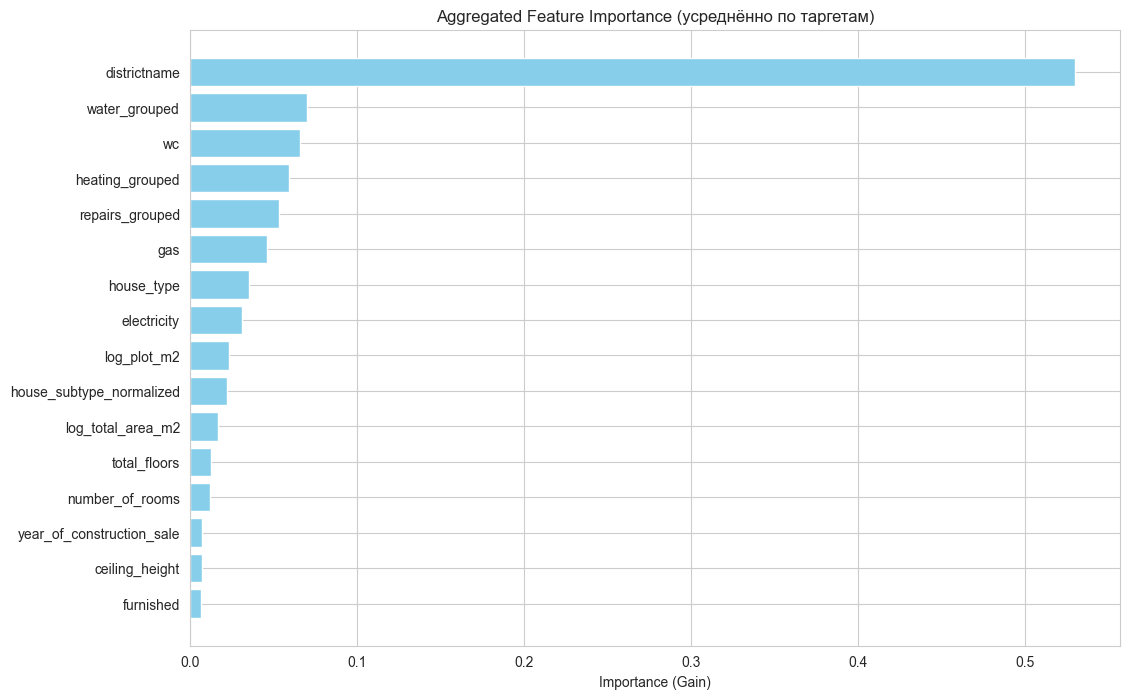

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

feature_names = X_train.columns.tolist()
n_targets = len(multi_target_model.estimators_)

# 1. Агрегация по категориальным признакам
aggregated_importance = {}
for cat_feature in categorical_cols:
    related_features = [i for i, f in enumerate(feature_names) if f.startswith(cat_feature + '_')]
    if not related_features:
        continue
    total_importance = 0
    for model in multi_target_model.estimators_:
        feat_imp = model.feature_importances_
        total_importance += np.sum([feat_imp[idx] for idx in related_features])
    aggregated_importance[cat_feature] = total_importance / n_targets  # усреднённая важность

# 2. Агрегация по числовым признакам (те, что не OHE)
all_cat_ohe = []
for c in categorical_cols:
    all_cat_ohe.extend([f for f in feature_names if f.startswith(c+'_')])
numeric_features = [f for f in feature_names if f not in all_cat_ohe]
for num_feat in numeric_features:
    total_importance = 0
    idx = feature_names.get_loc(num_feat) if hasattr(feature_names, "get_loc") else feature_names.index(num_feat)
    for model in multi_target_model.estimators_:
        feat_imp = model.feature_importances_
        total_importance += feat_imp[idx]
    aggregated_importance[num_feat] = total_importance / n_targets

# 3. Сортировка
sorted_importance = sorted(aggregated_importance.items(), key=lambda x: x[1], reverse=True)

# 4. Plot
if len(sorted_importance) > 0:
    features, importance = zip(*sorted_importance[:20])
    plt.figure(figsize=(12, 8))
    plt.barh(features, importance, color='skyblue')
    plt.title('Aggregated Feature Importance (усреднённо по таргетам)')
    plt.xlabel('Importance (Gain)')
    plt.gca().invert_yaxis()
    plt.show()
else:
    print("Нет значимых признаков для отображения.")

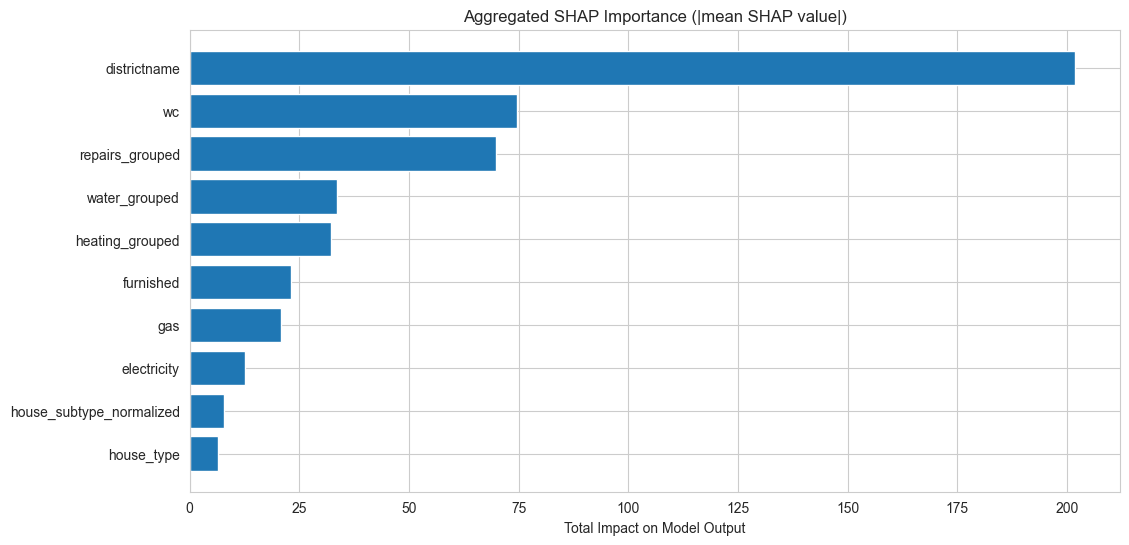

No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


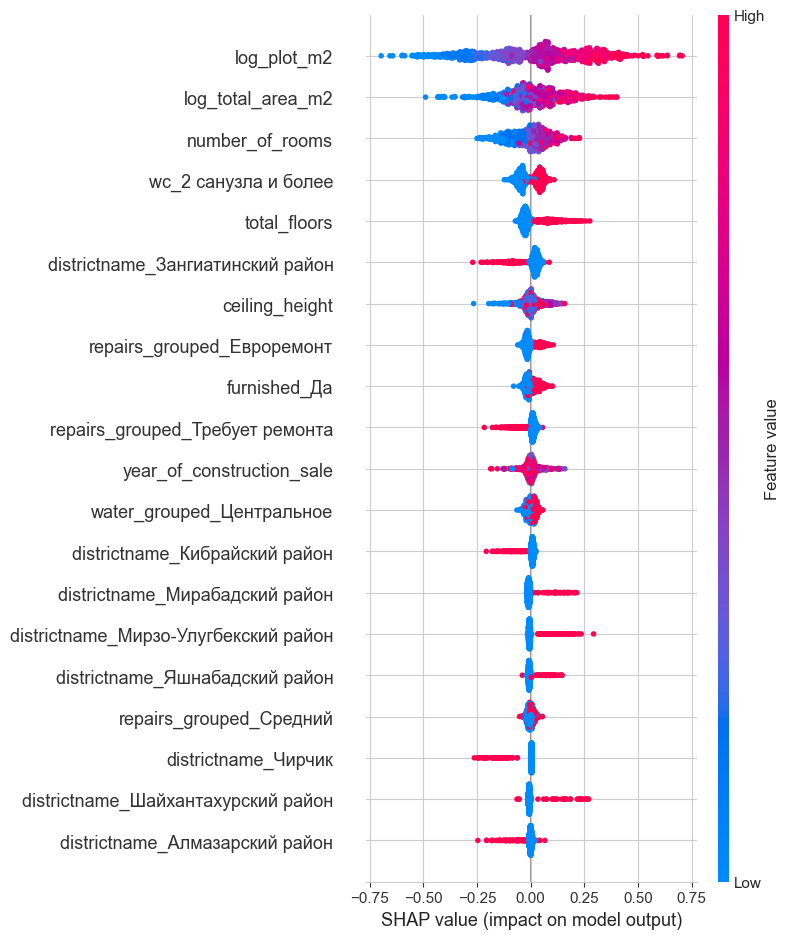

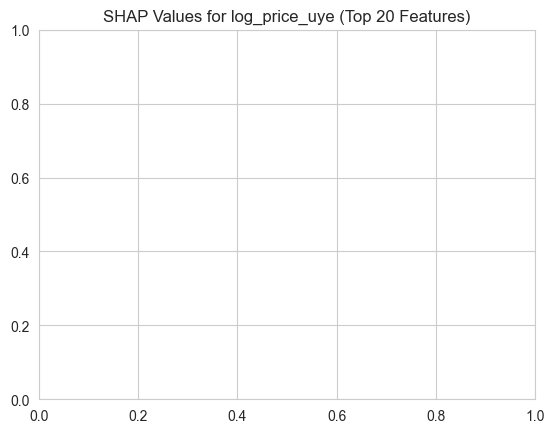

In [19]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings


# Инициализация SHAP
explainer = shap.Explainer(multi_target_model.estimators_[0], X_train)  # Для первого таргета (log_price_uye)
shap_values = explainer(X_test)

# --- Агрегация SHAP-значений для категориальных признаков ---
shap_df = pd.DataFrame(shap_values.values, columns=X_test.columns)
aggregated_shap = {}

# Суммируем абсолютные SHAP-значения для категориальных признаков (для их важности)
for cat_feature in categorical_cols:
    related_cols = [col for col in X_test.columns if col.startswith(cat_feature + '_')]
    if not related_cols:
        continue
    aggregated_shap[cat_feature] = np.abs(shap_df[related_cols]).sum().sum()  # Сумма по всем строкам и столбцам

# Добавляем числовые признаки
numeric_features = [col for col in X_test.columns if col not in categorical_cols and '_' not in col]
for num_feat in numeric_features:
    aggregated_shap[num_feat] = np.abs(shap_df[num_feat]).sum()

# Сортируем по важности
sorted_shap = sorted(aggregated_shap.items(), key=lambda x: x[1], reverse=True)

# --- Визуализация ---
# 1. Важность признаков (агрегированная)
features, importance = zip(*sorted_shap[:20])
plt.figure(figsize=(12, 6))
plt.barh(features, importance, color='#1f77b4')
plt.title('Aggregated SHAP Importance (|mean SHAP value|)')
plt.xlabel('Total Impact on Model Output')
plt.gca().invert_yaxis()
plt.show()

# 2. Beeswarm plot для первых 20 признаков (без агрегации)
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_test, max_display=20, plot_type='dot')
plt.title('SHAP Values for log_price_uye (Top 20 Features)')
plt.show()

In [15]:
from sklearn.metrics import mean_squared_log_error
import numpy as np
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    median_absolute_error
)

for i, col in enumerate(targets):
    y_true = np.expm1(y_test[col])
    y_pred_vals = np.expm1(y_pred[:, i])
    # Добавим обработку отрицательных значений (если вдруг они есть)
    y_true_pos = np.maximum(y_true, 0)
    y_pred_pos = np.maximum(y_pred_vals, 0)

    print(f"\n**Метрики для {col}:**")
    print(f"- R² (коэффициент детерминации): {r2_score(y_true, y_pred_vals):.3f}")
    print(f"- MAE (средняя абсолютная ошибка): {mean_absolute_error(y_true, y_pred_vals):.2f}")
    print(f"- MAPE (средняя % ошибка): {mean_absolute_percentage_error(y_true, y_pred_vals):.2%}")
    print(f"- RMSE (среднеквадратичная ошибка): {np.sqrt(mean_squared_error(y_true, y_pred_vals)):.2f}")
    print(f"- MedAE (медианная абсолютная ошибка): {median_absolute_error(y_true, y_pred_vals):.2f}")
    print(f"- RMSLE (среднеквадратичная логарифмическая ошибка): {np.sqrt(mean_squared_log_error(y_true_pos, y_pred_pos)):.4f}")


**Метрики для log_price_uye:**
- R² (коэффициент детерминации): 0.597
- MAE (средняя абсолютная ошибка): 33240.24
- MAPE (средняя % ошибка): 25.98%
- RMSE (среднеквадратичная ошибка): 47255.75
- MedAE (медианная абсолютная ошибка): 23756.84
- RMSLE (среднеквадратичная логарифмическая ошибка): 0.3208

**Метрики для log_price_area_per_m2:**
- R² (коэффициент детерминации): 0.343
- MAE (средняя абсолютная ошибка): 179.27
- MAPE (средняя % ошибка): 25.93%
- RMSE (среднеквадратичная ошибка): 237.57
- MedAE (медианная абсолютная ошибка): 135.67
- RMSLE (среднеквадратичная логарифмическая ошибка): 0.3209

**Метрики для log_price_plot_per_m2:**
- R² (коэффициент детерминации): 0.451
- MAE (средняя абсолютная ошибка): 84.24
- MAPE (средняя % ошибка): 26.54%
- RMSE (среднеквадратичная ошибка): 112.49
- MedAE (медианная абсолютная ошибка): 63.43
- RMSLE (среднеквадратичная логарифмическая ошибка): 0.3232


In [22]:
import numpy as np

def calculate_psi(expected, actual, buckets=10):
    def scale_range(input, min, max):
        input += -(np.min(input))
        input /= np.max(input) / (max - min)
        input += min
        return input

    # Создаём бины по train
    breakpoints = np.linspace(0, 100, buckets + 1)
    expected_perc = np.percentile(expected, breakpoints)
    expected_perc[0] = -np.inf
    expected_perc[-1] = np.inf

    expected_bins = np.histogram(expected, bins=expected_perc)[0] / len(expected)
    actual_bins = np.histogram(actual, bins=expected_perc)[0] / len(actual)

    psi = np.sum((expected_bins - actual_bins) * np.log((expected_bins + 1e-6) / (actual_bins + 1e-6)))
    return psi

# Пример для log_price_uye
psi_log_price = calculate_psi(
    y_train['log_price_uye'],
    y_test['log_price_uye']
)
print(f"PSI по log_price_uye: {psi_log_price:.4f}")

# Пример для log_price_area_per_m2
psi_log_price = calculate_psi(
    y_train['log_price_area_per_m2'],
    y_test['log_price_area_per_m2']
)
print(f"PSI по log_price_area_per_m2: {psi_log_price:.4f}")


# Пример для log_price_plot_per_m2
psi_log_price = calculate_psi(
    y_train['log_price_plot_per_m2'],
    y_test['log_price_plot_per_m2']
)
print(f"PSI по log_price_plot_per_m2: {psi_log_price:.4f}")






PSI по log_price_uye: 0.0103
PSI по log_price_area_per_m2: 0.0056
PSI по log_price_plot_per_m2: 0.0033


In [135]:
from scipy.stats import ks_2samp

# Для log_price_uye
ks_stat, ks_p = ks_2samp(
    y_train['log_price_uye'],
    y_test['log_price_uye']
)
print(f"KS-статистика: {ks_stat:.4f}, p-value: {ks_p:.4f}")

KS-статистика: 0.0291, p-value: 0.4467


In [133]:
from scipy.stats import ks_2samp

for col in targets:
    stat, pval = ks_2samp(y_train[col], y_test[col])
    print(f"{col}: KS-stat={stat:.3f}, p-value={pval:.3f}")

log_price_uye: KS-stat=0.029, p-value=0.447
log_price_area_per_m2: KS-stat=0.018, p-value=0.945
log_price_plot_per_m2: KS-stat=0.025, p-value=0.641


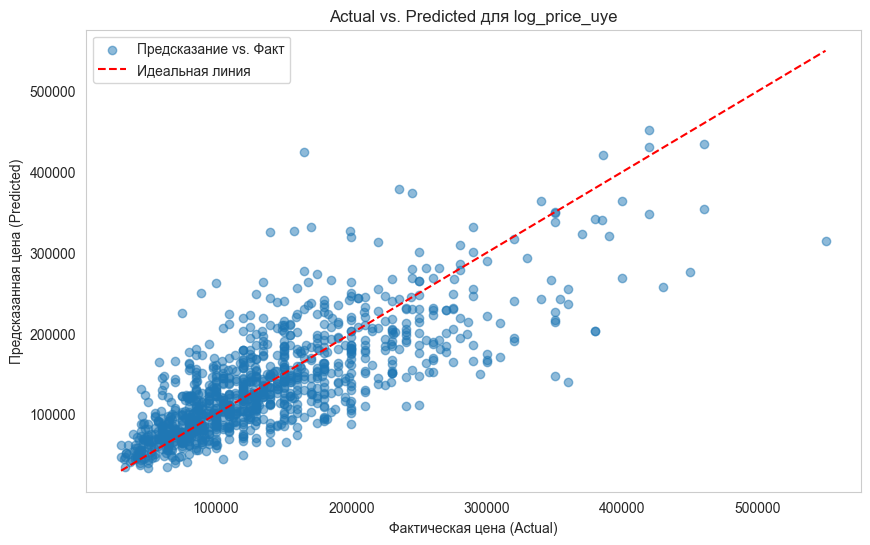

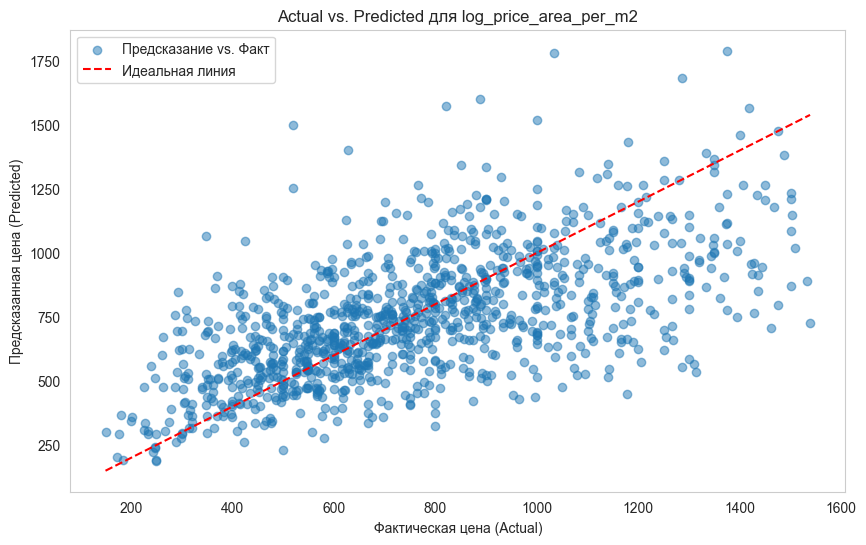

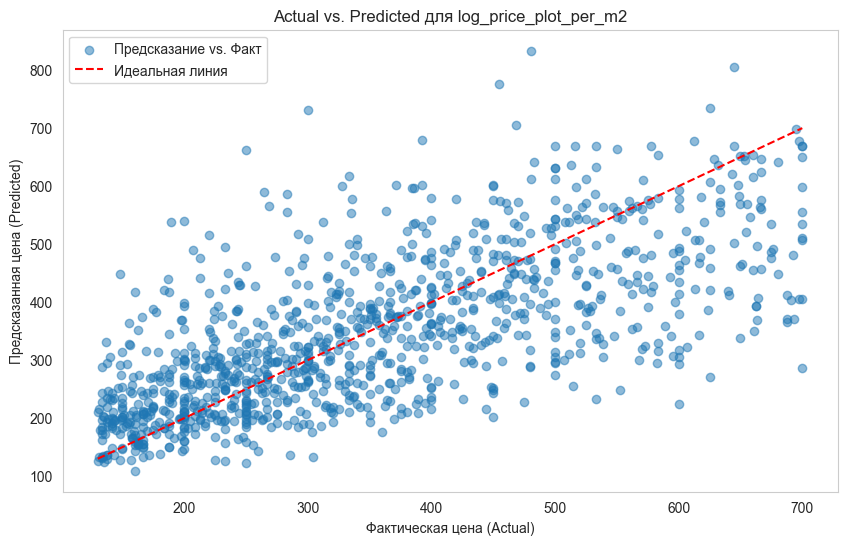

Text(129.99999999999994, 665.0, '$R^2$ = 0.441')

ValueError: Image size of 64609x245844 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 640x480 with 1 Axes>

In [131]:
import matplotlib.pyplot as plt

for i, col in enumerate(targets):
    y_true = np.expm1(y_test[col])
    y_pred_vals = np.expm1(y_pred[:, i])

    plt.figure(figsize=(10, 6))
    plt.scatter(y_true, y_pred_vals, alpha=0.5, label='Предсказание vs. Факт')
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--', label='Идеальная линия')
    plt.xlabel("Фактическая цена (Actual)")
    plt.ylabel("Предсказанная цена (Predicted)")
    plt.title(f"Actual vs. Predicted для {col}")
    plt.legend()
    plt.grid()
    plt.show()

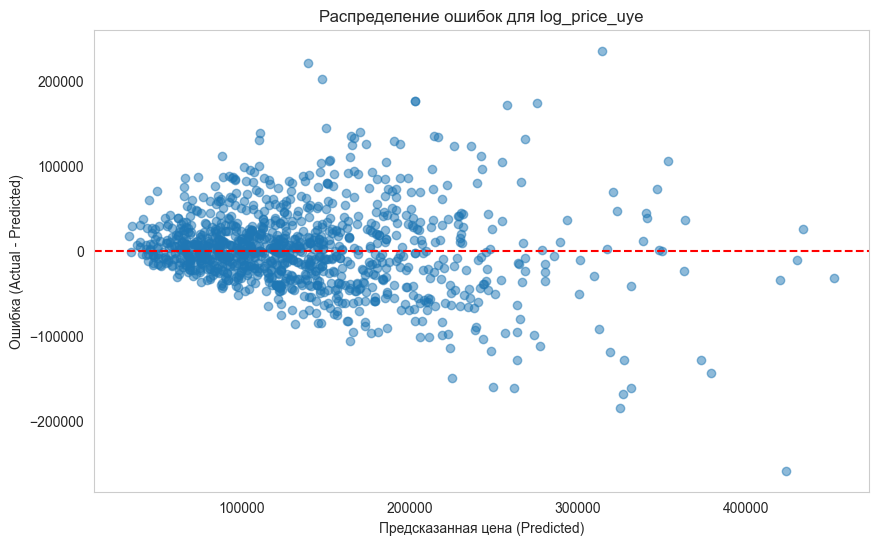

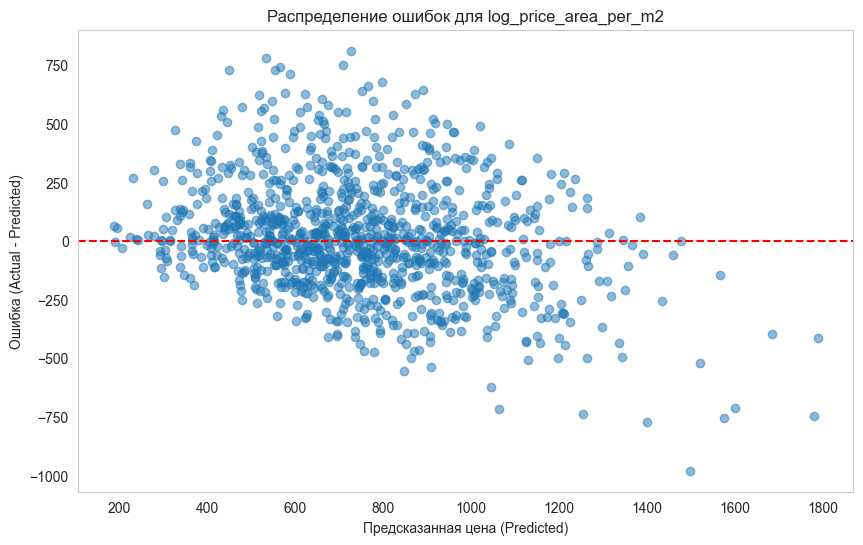

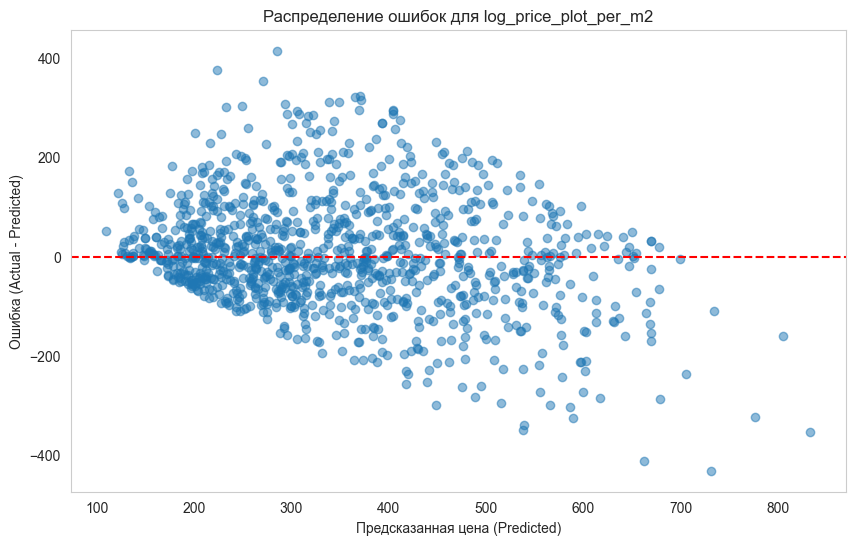

In [129]:
for i, col in enumerate(targets):
    y_true = np.expm1(y_test[col])
    y_pred_vals = np.expm1(y_pred[:, i])
    residuals = y_true - y_pred_vals  # Ошибки

    plt.figure(figsize=(10, 6))
    plt.scatter(y_pred_vals, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel("Предсказанная цена (Predicted)")
    plt.ylabel("Ошибка (Actual - Predicted)")
    plt.title(f"Распределение ошибок для {col}")
    plt.grid()
    plt.show()

TypeError: cannot convert the series to <class 'float'>

<Figure size 640x480 with 1 Axes>

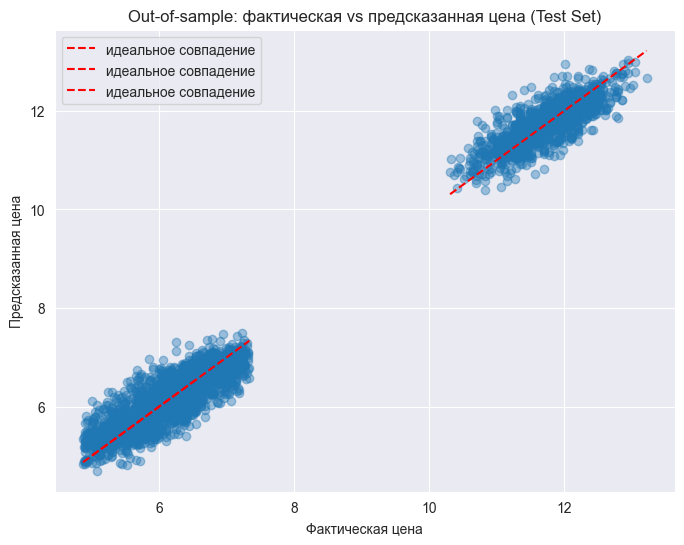

In [120]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)
plt.text(x=y_test.min(), y=y_test.max(), s=f"$R^2$ = {r2:.3f}", fontsize=12, color='white')

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='идеальное совпадение')
plt.xlabel("Фактическая цена")
plt.ylabel("Предсказанная цена")
plt.title("Out-of-sample: фактическая vs предсказанная цена (Test Set)")
plt.legend()
plt.grid(True)
plt.show()

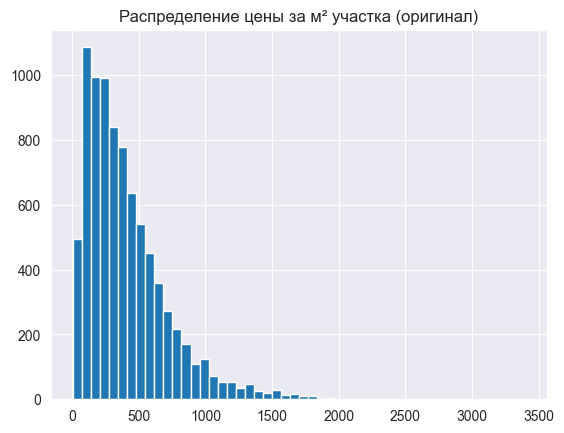

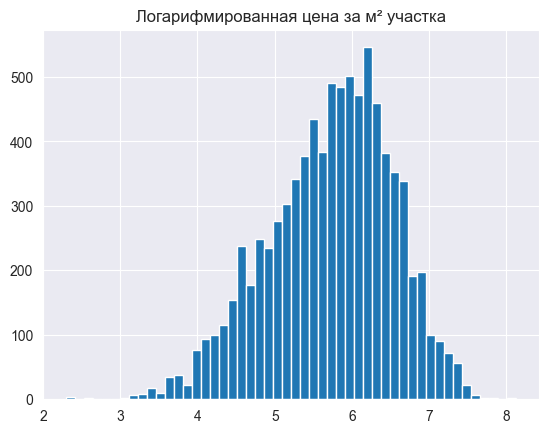

In [68]:
# До логарифмирования
plt.hist(df_cleaned['price_plot_per_m2_uye'], bins=50)
plt.title('Распределение цены за м² участка (оригинал)')
plt.show()

# После логарифмирования
plt.hist(np.log1p(df_cleaned['price_plot_per_m2_uye']), bins=50)
plt.title('Логарифмированная цена за м² участка')
plt.show()

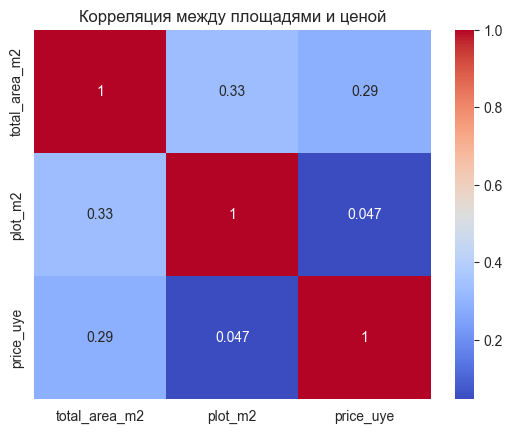

               price_uye  total_area_m2   plot_m2
price_uye       1.000000       0.286557  0.046690
total_area_m2   0.286557       1.000000  0.329492
plot_m2         0.046690       0.329492  1.000000


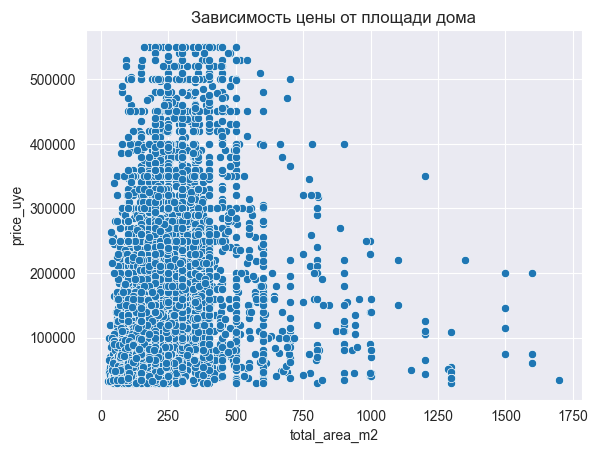

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

# Создаем новую фичу
df['area_ratio'] = df['plot_m2'] / df['total_area_m2']

# Смотрим корреляцию
corr_matrix = df[['total_area_m2', 'plot_m2', 'price_uye']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Корреляция между площадями и ценой')
plt.show()


# Корреляция цены с площадями
print(df[['price_uye', 'total_area_m2', 'plot_m2']].corr())

# График зависимости цены от площади дома
sns.scatterplot(x='total_area_m2', y='price_uye', data=df)
plt.title('Зависимость цены от площади дома')
plt.show()

In [71]:
%matplotlib inline

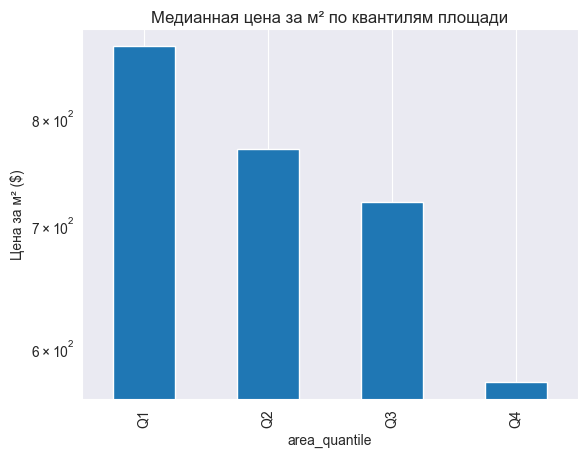

In [72]:
# Группировка по квантилям площади
df_cleaned['area_quantile'] = pd.qcut(df_cleaned['total_area_m2'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
price_trend = df_cleaned.groupby('area_quantile')['price_total_area_per_m2_uye'].median()

# График
price_trend.plot(kind='bar')
plt.title('Медианная цена за м² по квантилям площади')
plt.ylabel('Цена за м² ($)')
plt.yscale('log')  # Логарифмируем ось Y
plt.show()

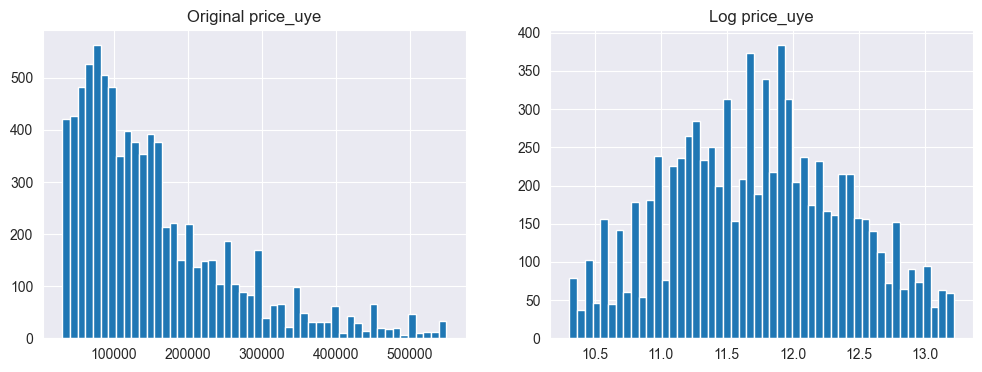

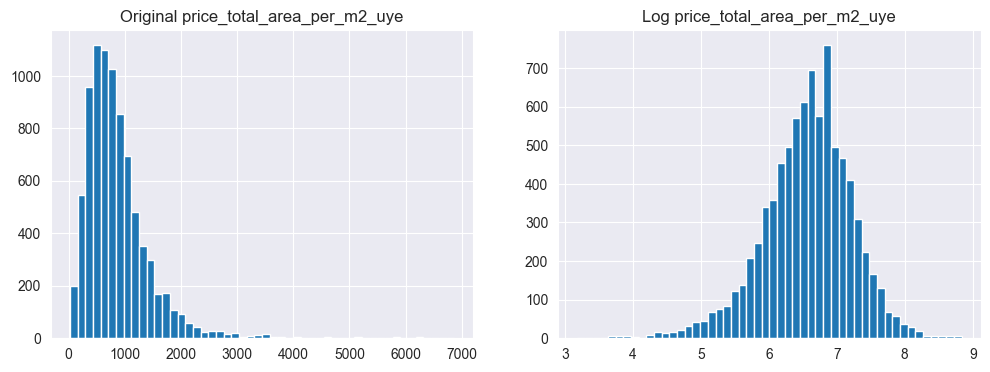

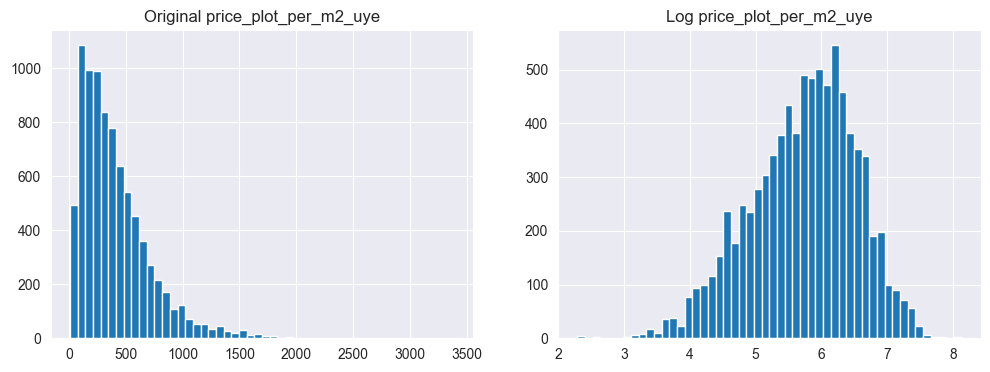

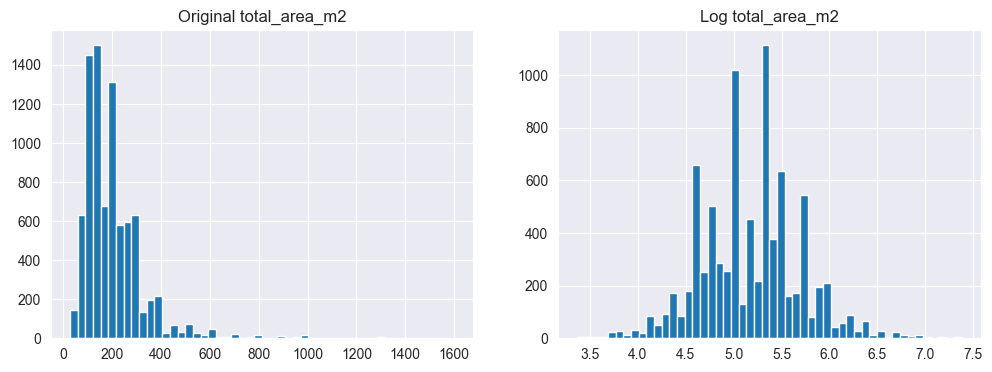

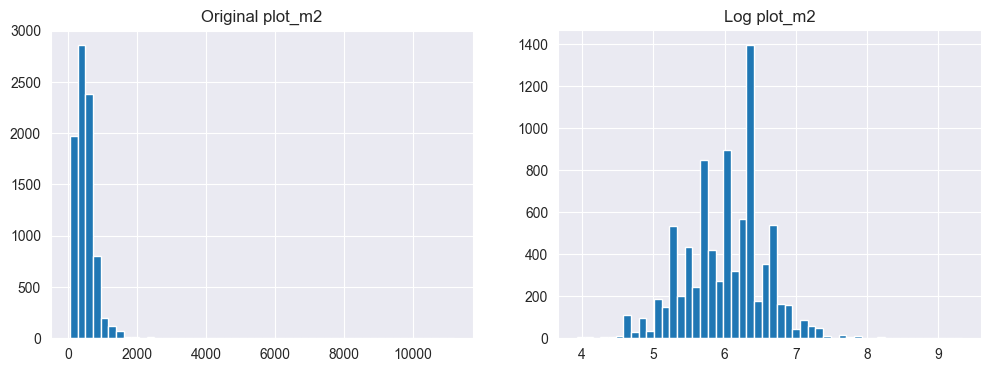

In [73]:
import matplotlib.pyplot as plt

# Для price_uye
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df_cleaned['price_uye'], bins=50)
plt.title('Original price_uye')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(df_cleaned['price_uye']), bins=50)
plt.title('Log price_uye')
plt.show()


# Для price_total_area_per_m2_uye
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df_cleaned['price_total_area_per_m2_uye'], bins=50)
plt.title('Original price_total_area_per_m2_uye')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(df_cleaned['price_total_area_per_m2_uye']), bins=50)
plt.title('Log price_total_area_per_m2_uye')
plt.show()



# Для price_plot_per_m2_uye
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df_cleaned['price_plot_per_m2_uye'], bins=50)
plt.title('Original price_plot_per_m2_uye')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(df_cleaned['price_plot_per_m2_uye']), bins=50)
plt.title('Log price_plot_per_m2_uye')
plt.show()





# Для total_area_m2
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df_cleaned['total_area_m2'], bins=50)
plt.title('Original total_area_m2')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(df_cleaned['total_area_m2']), bins=50)
plt.title('Log total_area_m2')
plt.show()

# Для total_area_m2
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df_cleaned['plot_m2'], bins=50)
plt.title('Original plot_m2')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(df_cleaned['plot_m2']), bins=50)
plt.title('Log plot_m2')
plt.show()

In [74]:
# Анализ распределения по районам
df_cleaned.groupby('districtname')['plot_m2'].describe(percentiles=[0.95])

,count,mean,std,min,50%,95%,max
districtname,,,,,,,
Аккурганский район,13.0,523.076923,212.735541,200.0,600.0,800.00,800.0
Алмазарский район,593.0,435.765767,245.267988,99.0,400.0,800.00,2500.0
Ангренский район,2.0,475.000000,35.355339,450.0,475.0,497.50,500.0
Ахангаранский район,48.0,754.797917,349.501253,90.0,631.5,1400.00,1600.0
Бекабадский район,14.0,550.000000,221.011660,100.0,600.0,840.00,1100.0
Бектемирский район,542.0,472.105166,299.254659,80.0,400.0,1000.00,4000.0
Бостанлыкский район,306.0,734.560131,335.254915,100.0,600.0,1400.00,2700.0
Букинский район,7.0,631.428571,141.707277,350.0,670.0,770.00,800.0
Зангиатинский район,1064.0,489.065789,391.570564,60.0,400.0,900.00,6500.0


In [75]:
# Проверим, какие есть уникальные значения
print(df['house_subtype'].value_counts(dropna=False))

# Оставим только "Дом" и "Часть дома" (если есть другие варианты, можешь их тоже указать)
df_sub = df[df['house_subtype'].isin(['Дом', 'Часть дома', 'Таунхаус', 'Флигель', 'Дача', 'Коттедж'])]


agg_metrics_full = (
    df_sub
    .groupby('house_subtype')
    .agg(
        count=('price', 'size'),
        min_area=('total_area_m2', 'min'),
        max_area=('total_area_m2', 'max'),
        mean_area=('total_area_m2', 'mean'),
        median_area=('total_area_m2', 'median'),
        std_area=('total_area_m2', 'std'),

        min_price=('price_uye', 'min'),
        max_price=('price_uye', 'max'),
        mean_price=('price_uye', 'mean'),
        median_price=('price_uye', 'median'),
        std_price=('price_uye', 'std'),

        min_rooms=('number_of_rooms', 'min'),
        max_rooms=('number_of_rooms', 'max'),
        mean_rooms=('number_of_rooms', 'mean'),
        median_rooms=('number_of_rooms', 'median'),
        std_rooms=('number_of_rooms', 'std'),


        min_plot=('plot_m2', 'min'),
        max_plot=('plot_m2', 'max'),
        mean_plot=('plot_m2', 'mean'),
        median_plot=('plot_m2', 'median'),
        std_plot=('plot_m2', 'std'),
    )
    .reset_index()
)


agg_metrics_full

KeyError: 'house_subtype'

In [ ]:
for k in [3, 5, 10]:
    nbrs = NearestNeighbors(n_neighbors=k).fit(X_train)
    distances, _ = nbrs.kneighbors(X_test)
    print(f"k={k}: Среднее расстояние = {distances.mean():.2f}")

## Ydataprofiling


In [ ]:

# Функция для распарсивания JSON-колонки
def parse_json_column(df_cleaned, column_name):
    try:
        # Преобразуем JSON-строки в словари
        df_cleaned[column_name] = df_cleaned[column_name].apply(lambda x: json.loads(x) if isinstance(x, str) else x)

        # Проверяем, есть ли вложенные данные в колонке
        if df_cleaned[column_name].apply(lambda x: isinstance(x, dict)).any():
            parsed_df = df_cleaned[column_name].apply(pd.Series).add_prefix(f"{column_name}_")
            df_cleaned = pd.concat([df_cleaned, parsed_df], axis=1)

        df_cleaned.drop(columns=[column_name], inplace=True)  # Удаляем оригинальную колонку
    except Exception as e:
        logging.warning(f"Ошибка при обработке колонки {column_name}: {e}")
    return df_cleaned


# Фильтруем регионы с более  чем 100 публикациями
region_counts = df_cleaned["regionname"].value_counts()
valid_regions = region_counts[region_counts > 100].index

# Создаем папку для отчетов
output_dir = "houses_reports"
os.makedirs(output_dir, exist_ok=True)

# Функция для очистки имен файлов
def clean_filename(name):
    return re.sub(r'[\\/*?:"<>|]', "_", name)

columns_to_exclude = ["description", "location"]

# Генерируем отчеты ydata_profiling по каждому региону
for region in valid_regions:
    region_df = df_cleaned[df_cleaned["regionname"] == region].copy()
    region_df = region_df.drop(columns=[col for col in columns_to_exclude if col in region_df.columns])
    if not region_df.empty:  # Проверка на пустоту
        profile = ProfileReport(region_df, title=f"Отчет по региону {region}", explorative=True)
        profile.to_file(f"{output_dir}/profile_{clean_filename(region)}.html")
        logging.info(f"Отчет для региона {region} сохранен.")

logging.info("Готово! Отчеты сохранены в файлы.")

In [47]:
from ydata_profiling import ProfileReport
import pandas as pd
import numpy as np
import json
import logging
import os
import re

# Настройка логирования
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)

# Ваши существующие функции
def parse_json_column(df_cleaned, column_name):
    try:
        df_cleaned[column_name] = df_cleaned[column_name].apply(lambda x: json.loads(x) if isinstance(x, str) else x)
        if df_cleaned[column_name].apply(lambda x: isinstance(x, dict)).any():
            parsed_df = df_cleaned[column_name].apply(pd.Series).add_prefix(f"{column_name}_")
            df_cleaned = pd.concat([df_cleaned, parsed_df], axis=1)
        df_cleaned.drop(columns=[column_name], inplace=True)
    except Exception as e:
        logging.warning(f"Ошибка при обработке колонки {column_name}: {e}")
    return df_cleaned

def clean_filename(name):
    return re.sub(r'[\\/*?:"<>|]', "_", name)

def add_custom_stats(df):
    """Добавляет расширенные статистики в DataFrame"""
    desc = {}
    for col in df.select_dtypes(include=[np.number]).columns:
        try:
            desc[col] = {
                'min': float(df[col].min()),
                '5th_percentile': float(df[col].quantile(0.05)),
                'Q1': float(df[col].quantile(0.25)),
                'median': float(df[col].median()),
                'Q3': float(df[col].quantile(0.75)),
                '80th_percentile': float(df[col].quantile(0.80)),
                '85th_percentile': float(df[col].quantile(0.85)),
                '90th_percentile': float(df[col].quantile(0.90)),
                '95th_percentile': float(df[col].quantile(0.95)),
                'max': float(df[col].max())
            }
        except Exception as e:
            logging.warning(f"Не удалось вычислить статистики для колонки {col}: {e}")
    df.attrs['description'] = desc
    return df

# Основной процесс
def generate_reports(df_cleaned):
    try:
        # Фильтрация регионов
        region_counts = df_cleaned["regionname"].value_counts()
        valid_regions = region_counts[region_counts > 100].index

        # Создание папки для отчетов
        output_dir = "houses_reports"
        os.makedirs(output_dir, exist_ok=True)

        columns_to_exclude = ["description", "location"]

        for region in valid_regions:
            try:
                # Подготовка данных
                region_df = df_cleaned[df_cleaned["regionname"] == region].copy()
                region_df = region_df.drop(columns=[col for col in columns_to_exclude if col in region_df.columns])

                if not region_df.empty:
                    # Добавляем кастомные статистики
                    region_df = add_custom_stats(region_df)

                    # Создаем отчет без lazy-инициализации
                    profile = ProfileReport(
                        region_df,
                        title=f"Отчет по региону {region}",
                        explorative=True,
                        minimal=False,
                        lazy=False  # Отключаем ленивую инициализацию
                    )

                    # Сохранение отчета
                    report_path = f"{output_dir}/profile_{clean_filename(region)}.html"
                    profile.to_file(report_path)

                    # Дополнительные статистики в CSV
                    stats = []
                    for col in region_df.select_dtypes(include=[np.number]).columns:
                        try:
                            stats.append({
                                'column': col,
                                'min': region_df[col].min(),
                                '5th': region_df[col].quantile(0.05),
                                'Q1': region_df[col].quantile(0.25),
                                'median': region_df[col].median(),
                                'Q3': region_df[col].quantile(0.75),
                                '80th': region_df[col].quantile(0.80),
                                '85th': region_df[col].quantile(0.85),
                                '90th': region_df[col].quantile(0.90),
                                '95th': region_df[col].quantile(0.95),
                                'max': region_df[col].max()
                            })
                        except Exception as e:
                            logging.warning(f"Не удалось вычислить статистики для колонки {col} в регионе {region}: {e}")

                    stats_df = pd.DataFrame(stats)
                    if not stats_df.empty:
                        stats_df.to_csv(
                            f"{output_dir}/extra_stats_{clean_filename(region)}.csv",
                            index=False
                        )

                    logging.info(f"Отчет для региона {region} успешно сохранен")
                else:
                    logging.warning(f"Нет данных для региона {region}")

            except Exception as e:
                logging.error(f"Ошибка при обработке региона {region}: {str(e)}", exc_info=True)

        logging.info("Все отчеты успешно сгенерированы")
        return True

    except Exception as e:
        logging.error(f"Критическая ошибка при генерации отчетов: {str(e)}", exc_info=True)
        return False

# Запуск процесса
if __name__ == "__main__":
    generate_reports(df_cleaned)

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 80.55it/s]
2025-07-11 10:03:49,749 - INFO - Отчет для региона Ташкентская область успешно сохранен
2025-07-11 10:03:49,749 - INFO - Все отчеты успешно сгенерированы


In [48]:
import pandas as pd

# Загружаем файл
df = pd.read_csv('/Users/gulimoh/collateral-assessment/ydata_profiling/houses_reports/houses_reports/extra_stats_Ташкентская область.csv')

# Список нужных значений
target_columns = [
    'price_total_area_per_m2_uye',
    'price_plot_per_m2_uye',
    'price_uye',
    'total_area_m2',
    'plot_m2'
]

# Оставляем только нужные строки
filtered_df = df[df['column'].isin(target_columns)]

# Сохраняем результат
filtered_df.to_csv('_file.csv', index=False)

In [ ]:
import pandas as pd

def value_distribution(df, column, top_n=100):
    print(f"\n=== 📊 {column.upper()} ===")

    # Заменим пропуски на "(Missing)" и приводим к строковому типу
    series = df[column].fillna("(Missing)").astype(str)

    # Подсчёт значений
    counts = series.value_counts(dropna=False)
    freqs = series.value_counts(normalize=True, dropna=False) * 100

    # Отдельно обрабатываем (Missing)
    if "(Missing)" in counts:
        missing_count = counts["(Missing)"]
        missing_freq = freqs["(Missing)"]
        counts = counts.drop("(Missing)")
        freqs = freqs.drop("(Missing)")
    else:
        missing_count = 0
        missing_freq = 0.0

    # Топ-N значений
    top_counts = counts.head(top_n)
    top_freqs = freqs.head(top_n)

    # Остальные — как "Other values"
    if len(counts) > top_n:
        other_count = counts.iloc[top_n:].sum()
        other_freq = freqs.iloc[top_n:].sum()
        top_counts["Other values"] = other_count
        top_freqs["Other values"] = other_freq

    # Добавляем обратно "(Missing)"
    if missing_count > 0:
        top_counts["(Missing)"] = missing_count
        top_freqs["(Missing)"] = missing_freq

    # Финальная таблица
    result = pd.DataFrame({
        "Count": top_counts.astype(int),
        "Frequency (%)": top_freqs.round(1)
    })

    print(result)
    result
    return result

# Указываем интересующие колонки
columns_to_check = ["water_grouped", "heating_grouped", "repairs_grouped", "house_subtype_normalized"]

# Проход по всем колонкам
distributions = {}
for col in columns_to_check:
    if col in df.columns:
        distributions[col] = value_distribution(df, col)
    else:
        print(f"\n[!] Колонка {col} отсутствует в DataFrame.")



In [29]:
df["number_of_rooms"].describe()

KeyError: 'number_of_rooms'

In [ ]:
df_problem = df[
    (df["plot_m2"].notna()) &
    (df["total_area_m2"].notna()) &
    (df["plot_m2"] < df["total_area_m2"])
    ]
print(f"Количество объявлений, где plot_m2 <= total_area_m2: {len(df_problem)}")

# df_problem[["plot", "plot_m2", "total_area", "total_area_m2", "title", "description"]]


import pandas as pd
# Посмотрим распределение значений plot
df["total_area"].describe()
# Подозрение на сотки
# df[df["plot"] < 50][["plot", "title", "description"]]

In [ ]:
import pandas as pd
# Посмотрим распределение значений plot
df["total_area"].describe()
# Подозрение на сотки
# df[df["plot"] < 50][["plot", "title", "description"]]